In [4]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [6]:
url = "https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,currencies"

response = requests.get(url, timeout=20)
response.raise_for_status()

data = response.json()

print(f"Pobrano {len(data)} rekordów z API.")

Pobrano 250 rekordów z API.


In [7]:
def get_currency(currencies_dict):
    if currencies_dict:
        return list(currencies_dict.keys())[0]
    return None

In [9]:
kraje_lista = []

for kraj in data:
    nazwa = kraj.get("name", {}).get("common")

    capital_list = kraj.get("capital")
    stolica = capital_list[0] if capital_list else None

    region = kraj.get("region")
    subregion = kraj.get("subregion")
    populacja = kraj.get("population")
    powierzchnia = kraj.get("area")
    waluta = get_currency(kraj.get("currencies"))

    kraje_lista.append({
        "nazwa": nazwa,
        "stolica": stolica,
        "region": region,
        "subregion": subregion,
        "populacja": populacja,
        "powierzchnia": powierzchnia,
        "waluta": waluta
    })

df_kraje = pd.DataFrame(kraje_lista)

In [10]:
df_kraje.head()

,nazwa,stolica,region,subregion,populacja,powierzchnia,waluta
0,Ivory Coast,Yamoussoukro,Africa,Western Africa,31719275,322463.0,XOF
1,Italy,Rome,Europe,Southern Europe,58927633,301336.0,EUR
2,Kyrgyzstan,Bishkek,Asia,Central Asia,7281800,199951.0,KGS
3,Papua New Guinea,Port Moresby,Oceania,Melanesia,11781559,462840.0,PGK
4,Fiji,Suva,Oceania,Melanesia,900869,18272.0,FJD


In [11]:
df_kraje.shape

(250, 7)

In [12]:
df_kraje.dtypes

nazwa               str
stolica             str
region              str
subregion           str
populacja         int64
powierzchnia    float64
waluta              str
dtype: object

In [13]:
conn = sqlite3.connect("kraje_swiata.db")

df_kraje.to_sql("kraje", conn, if_exists="replace", index=False)

print("Tabela 'kraje' została zapisana do bazy kraje_swiata.db")

Tabela 'kraje' została zapisana do bazy kraje_swiata.db


In [14]:
df_populacja_swiata = pd.read_sql_query("""
    SELECT SUM(populacja) AS laczna_populacja_swiata
    FROM kraje
""", conn)

df_populacja_swiata

,laczna_populacja_swiata
0,8019495460


In [15]:
df_top10_populacja = pd.read_sql_query("""
    SELECT nazwa, populacja
    FROM kraje
    ORDER BY populacja DESC
    LIMIT 10
""", conn)

df_top10_populacja

,nazwa,populacja
0,India,1417492000
1,China,1408280000
2,United States,340110988
3,Indonesia,284438782
4,Pakistan,241499431
5,Nigeria,223800000
6,Brazil,213421037
7,Bangladesh,169828911
8,Russia,146028325
9,Mexico,130575786


In [16]:
df_regiony = pd.read_sql_query("""
    SELECT
        region,
        COUNT(*) AS liczba_krajow,
        ROUND(AVG(populacja), 2) AS srednia_populacja
    FROM kraje
    GROUP BY region
    ORDER BY liczba_krajow DESC
""", conn)

df_regiony

,region,liczba_krajow,srednia_populacja
0,Africa,59,24787532.39
1,Americas,56,18617496.13
2,Europe,53,13993545.70
3,Asia,50,94494639.32
4,Oceania,27,1779988.07
5,Antarctic,5,340.00


In [17]:
df_wieksze_od_polski = pd.read_sql_query("""
    SELECT nazwa, powierzchnia
    FROM kraje
    WHERE powierzchnia > 312679
    ORDER BY powierzchnia DESC
""", conn)

df_wieksze_od_polski

,nazwa,powierzchnia
0,Russia,17098246.0
1,Antarctica,14000000.0
2,Canada,9984670.0
3,China,9706961.0
4,United States,9525067.0
...,...,...
66,Republic of the Congo,342000.0
67,Finland,338455.0
68,Vietnam,331212.0
69,Malaysia,330803.0


In [18]:
df_gestosc = pd.read_sql_query("""
    SELECT
        nazwa,
        populacja,
        powierzchnia,
        ROUND(populacja * 1.0 / powierzchnia, 2) AS gestosc_zaludnienia
    FROM kraje
    WHERE powierzchnia IS NOT NULL
      AND powierzchnia > 0
      AND populacja IS NOT NULL
    ORDER BY gestosc_zaludnienia DESC
    LIMIT 1
""", conn)

df_gestosc

,nazwa,populacja,powierzchnia,gestosc_zaludnienia
0,Macau,685900,30.0,22863.33


In [19]:
df_populacja_regionow = pd.read_sql_query("""
    SELECT
        region,
        SUM(populacja) AS laczna_populacja
    FROM kraje
    WHERE region IS NOT NULL
      AND region != ''
    GROUP BY region
    ORDER BY laczna_populacja DESC
""", conn)

df_populacja_regionow

,region,laczna_populacja
0,Asia,4724731966
1,Africa,1462464411
2,Americas,1042579783
3,Europe,741657922
4,Oceania,48059678
5,Antarctic,1700


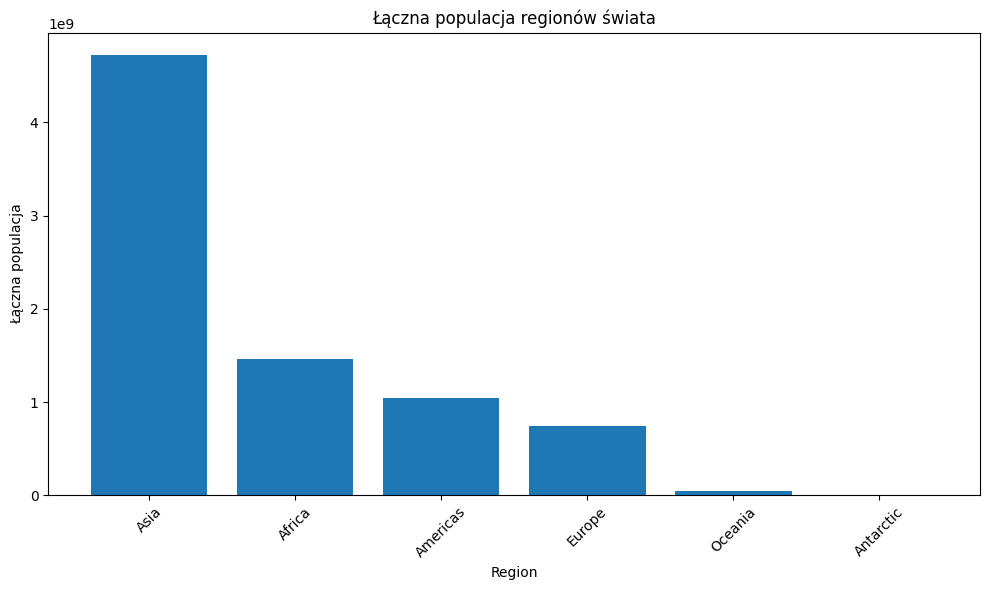

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(df_populacja_regionow["region"], df_populacja_regionow["laczna_populacja"])
plt.title("Łączna populacja regionów świata")
plt.xlabel("Region")
plt.ylabel("Łączna populacja")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
conn.close()